# Introduction

**Goal**: Apply OGSE spot mask for camera tests.

A set of sources (point + extended) is injected in the given simulation object, following the description of the OGSE spot masks for camera tests (PLATO-DLR-PL-TN-0069).

All small spots are point sources of the given magnitude.  The flux of extended source should be scaled according to the number of illuminated pixels (in absence of a PSF, all illuminated pixels should receive the same flux).

As the mask can be rotated in the OGSE, the orientation angle of the mask reference frame w.r.t. the CCD reference frame is given.

# Configure the Simulation

In [1]:
from simulation import Simulation
import os
from SpotMask import insert_ogse_spot_mask
from hdf5ToFits import hdf5ToFits

In [2]:
# Create a Simulation object, here with the name "ogse-spot-mask"

simulation_name = "ogse-spot-mask"
sim = Simulation(simulation_name)

# Specify the folder where the output files should be stored
# (they all will have the name "ogse-spot-mask")

sim.outputDir = os.environ["PLATO_WORKDIR"]


## Configure the Observation

In [3]:
# Specify the number of exposures

sim["ObservingParameters/NumExposures"] = 10

# Specify the cycle time (i.e. sum of the exposure time and the readout time before the next exposure starts)

sim["ObservingParameters/CycleTime"] = 25

## Configure the Sky

In [4]:
# Specify the background contribution [photons/pixel/s]

sim["Sky/SkyBackground"] = 0

# Specify whether or not you want to include cosmic hits

sim["Sky/IncludeCosmicsInSubField"] = "yes"

## Specify the Platform

In [5]:
# Don't include jitter

sim["Platform/UseJitter"] = "no"

## Specify the Telescope

In [6]:
# Specify which telescope group you are using
# (can be 1/2/3/4/"Fast")

sim["Telescope/GroupID"] = 1

# Don't include drift

sim["Telescope/UseDrift"] = "no"

## Specify the Camera

In [7]:
# Disable aberration correction

sim["Camera/IncludeAberrationCorrection"] = "no"

# Specify whether or not you want to include field distortion

sim["Camera/IncludeFieldDistortion"] = "no"

# Specify the PSF

In [8]:
# Specify the type of PSF you want to use
# Options are: "MappedFromFileAsymmetrical", "MappedFromFileSymmetrical", "Mapped Gaussian", and "AnalyticNonGaussian"

sim["PSF/Model"] = "MappedFromFileAsymmetrical"

## Configure the FEE

(N.A.)

## Configure the CCD

In [9]:
# Specify which CCD you are using (1/2/3/4)

sim["CCD/Position"] = 2

# Specify the readout mode: "Nominal" or "Partial"

sim["CCD/ReadoutMode/ReadoutMode"] = "Nominal"

# When using partial-readout mode, specify how many rows should be read out and starting from which row

if sim["CCD/ReadoutMode/ReadoutMode"] == "Partial":
    
    sim["CCD/ReadoutMode/Partial/FirstRowReadout"] = 0
    sim["CCD/ReadoutMode/Partial/NumRowsReadout"] = 4510

# Specify which effects you want to include in the simulation

sim["CCD/IncludeFlatfield"] = "yes"
sim["CCD/IncludeDarkSignal"] = "yes"
sim["CCD/IncludeBFE"] = "yes"
sim["CCD/IncludePhotonNoise"] = "yes"
sim["CCD/IncludeReadoutNoise"] = "yes"
sim["CCD/IncludeCTIeffects"] = "yes"
sim["CCD/IncludeChargeInjection"] = "no"
sim["CCD/IncludeOpenShutterSmearing"] = "yes"
sim["CCD/IncludeQuantumEfficiency"] = "yes"
sim["CCD/IncludeRelativeTransmissivity"] = "yes"
sim["CCD/IncludePolarization"] = "yes"
sim["CCD/IncludeParticulateContamination"] = "yes"
sim["CCD/IncludeMolecularContamination"] = "yes"
sim["CCD/IncludeConvolution"] = "yes"
sim["CCD/IncludeFullWellSaturation"] = "yes"
sim["CCD/IncludeDigitalSaturation"] = "yes"
sim["CCD/IncludeQuantisation"] = "yes"

## Configure the Sub-Field

In [10]:
# Specify where the lower left corner (row, column) of the sub-field is in the CCD reference frame [pixels]

sim["SubField/ZeroPointRow"] = 0
sim["SubField/ZeroPointColumn"] = 0

# Specify the dimensions of the sub-field [pixels]

sim["SubField/NumRows"] = 100
sim["SubField/NumColumns"] = 100

# Specify the sub-pixel resolution

sim["SubField/SubPixels"] = 8

# Insert the OGSE Spot Mask

In [11]:
# Magnitude of the sources to insert

magnitude = 10

# Rotation angle of the mask reference frame w.r.t. the CCD reference frame [degrees]

rotation_angle_mask = 0

insert_ogse_spot_mask(sim, magnitude, rotation_angle_mask=0)

# Execute the Simulation

In [12]:
# Execute the simulation
# (any existing files will be overwritten)

simFile = sim.run(removeOutputFile=True)

# Image Inspection

In [13]:
# The index of the exposure you want to inspect (counting starts at zero)

exposure = 0

## Visualisation

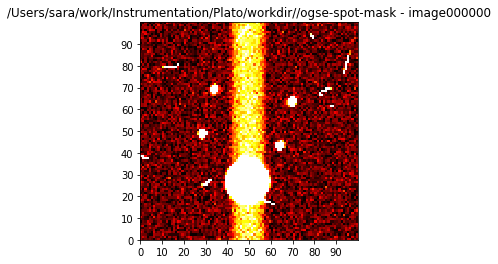

In [14]:
simFile.showImage(exposure)

## Extract images

In [15]:
# Extract an exposure into a numpy array

image = simFile.getImage(0)

# Conversion from HDF5 to FITS

In [17]:
input_filename = sim.outputDir + simulation_name + ".hdf5"
output_filename = sim.outputDir + simulation_name + ".fits"

# Convert the output HDF5 file to a FITS file with the same name,
# stored in the same directory

hdf5ToFits(input_filename, output_filename)